# Comprehensive Language Analysis (Lang2Vec)
This notebook mirrors the Lang2Vec clustering pipeline: it loads the filtered FLORES language list, builds Lang2Vec distance matrices, and runs auto-`k` agglomerative clustering (silhouette score 0.394 vs 0.387 for HDBSCAN, per `compare_clustering_strategies.py`), then visualizes the MDS projections, plots silhouette diagnostics, and emits the three routing tiers used for expert selection.


In [192]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [193]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Image
PROJECT_ROOT = Path('..').resolve().parent
SCRIPT_DIR = PROJECT_ROOT / 'data_prep' / 'lang_cluster_analysis'
PROCESSED_DIR = PROJECT_ROOT / 'data_prep' / 'processed_artifacts'
PROCESSED_DIR.mkdir(exist_ok=True, parents=True)

from cluster_lang2vec_distances import (
    auto_k,
    build_distance_matrix,
    compute_silhouettes,
    load_langs,
    parse_language_spec,
    plot_distance_projection,
    plot_selection_highlight,
    plot_silhouette,
    save_clusters,
    select_top_per_cluster,
    cluster_with_k
)
from prepare_lang_subset_tiers import (
    build_cluster_stats,
    select_tier2_clusters
)

## Load Lang2Vec distances and run auto-`k` agglomerative clustering
> We standardize on agglomerative clustering here because the silhouette comparison script measured it at 0.394 versus 0.387 for HDBSCAN on Lang2Vec genetic distances.


In [194]:
distance_type = 'genetic'
method = 'average'
min_k = 1
max_k = 192
auto_k_min_cluster_size = 1
languages = None  # use all FLORES languages in filtered_languages.csv
# (Silhouette: agglomerative 0.394 vs HDBSCAN 0.387) - agglomerative gave the cleaner clustering.


In [195]:
langs, families = load_langs(parse_language_spec(languages))
matrix = build_distance_matrix(langs, distance_type)
print(f'Loaded {len(langs)} languages for Lang2Vec analysis')
k, silhouette_scores = auto_k(matrix, min_k, max_k, method, min_cluster_size=auto_k_min_cluster_size)
print(f'Auto-selected k={k}')
labels = cluster_with_k(matrix, k, method)
tier3_path = PROCESSED_DIR / f'clusters_lang2vec_{distance_type}_notebook.json'
save_clusters(langs, labels, tier3_path)
print(f'Saved full cluster map to {tier3_path}')

Loaded 184 languages for Lang2Vec analysis
Auto-selected k=37
Saved full cluster map to /home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/processed_artifacts/clusters_lang2vec_genetic_notebook.json


## MDS visualizations

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


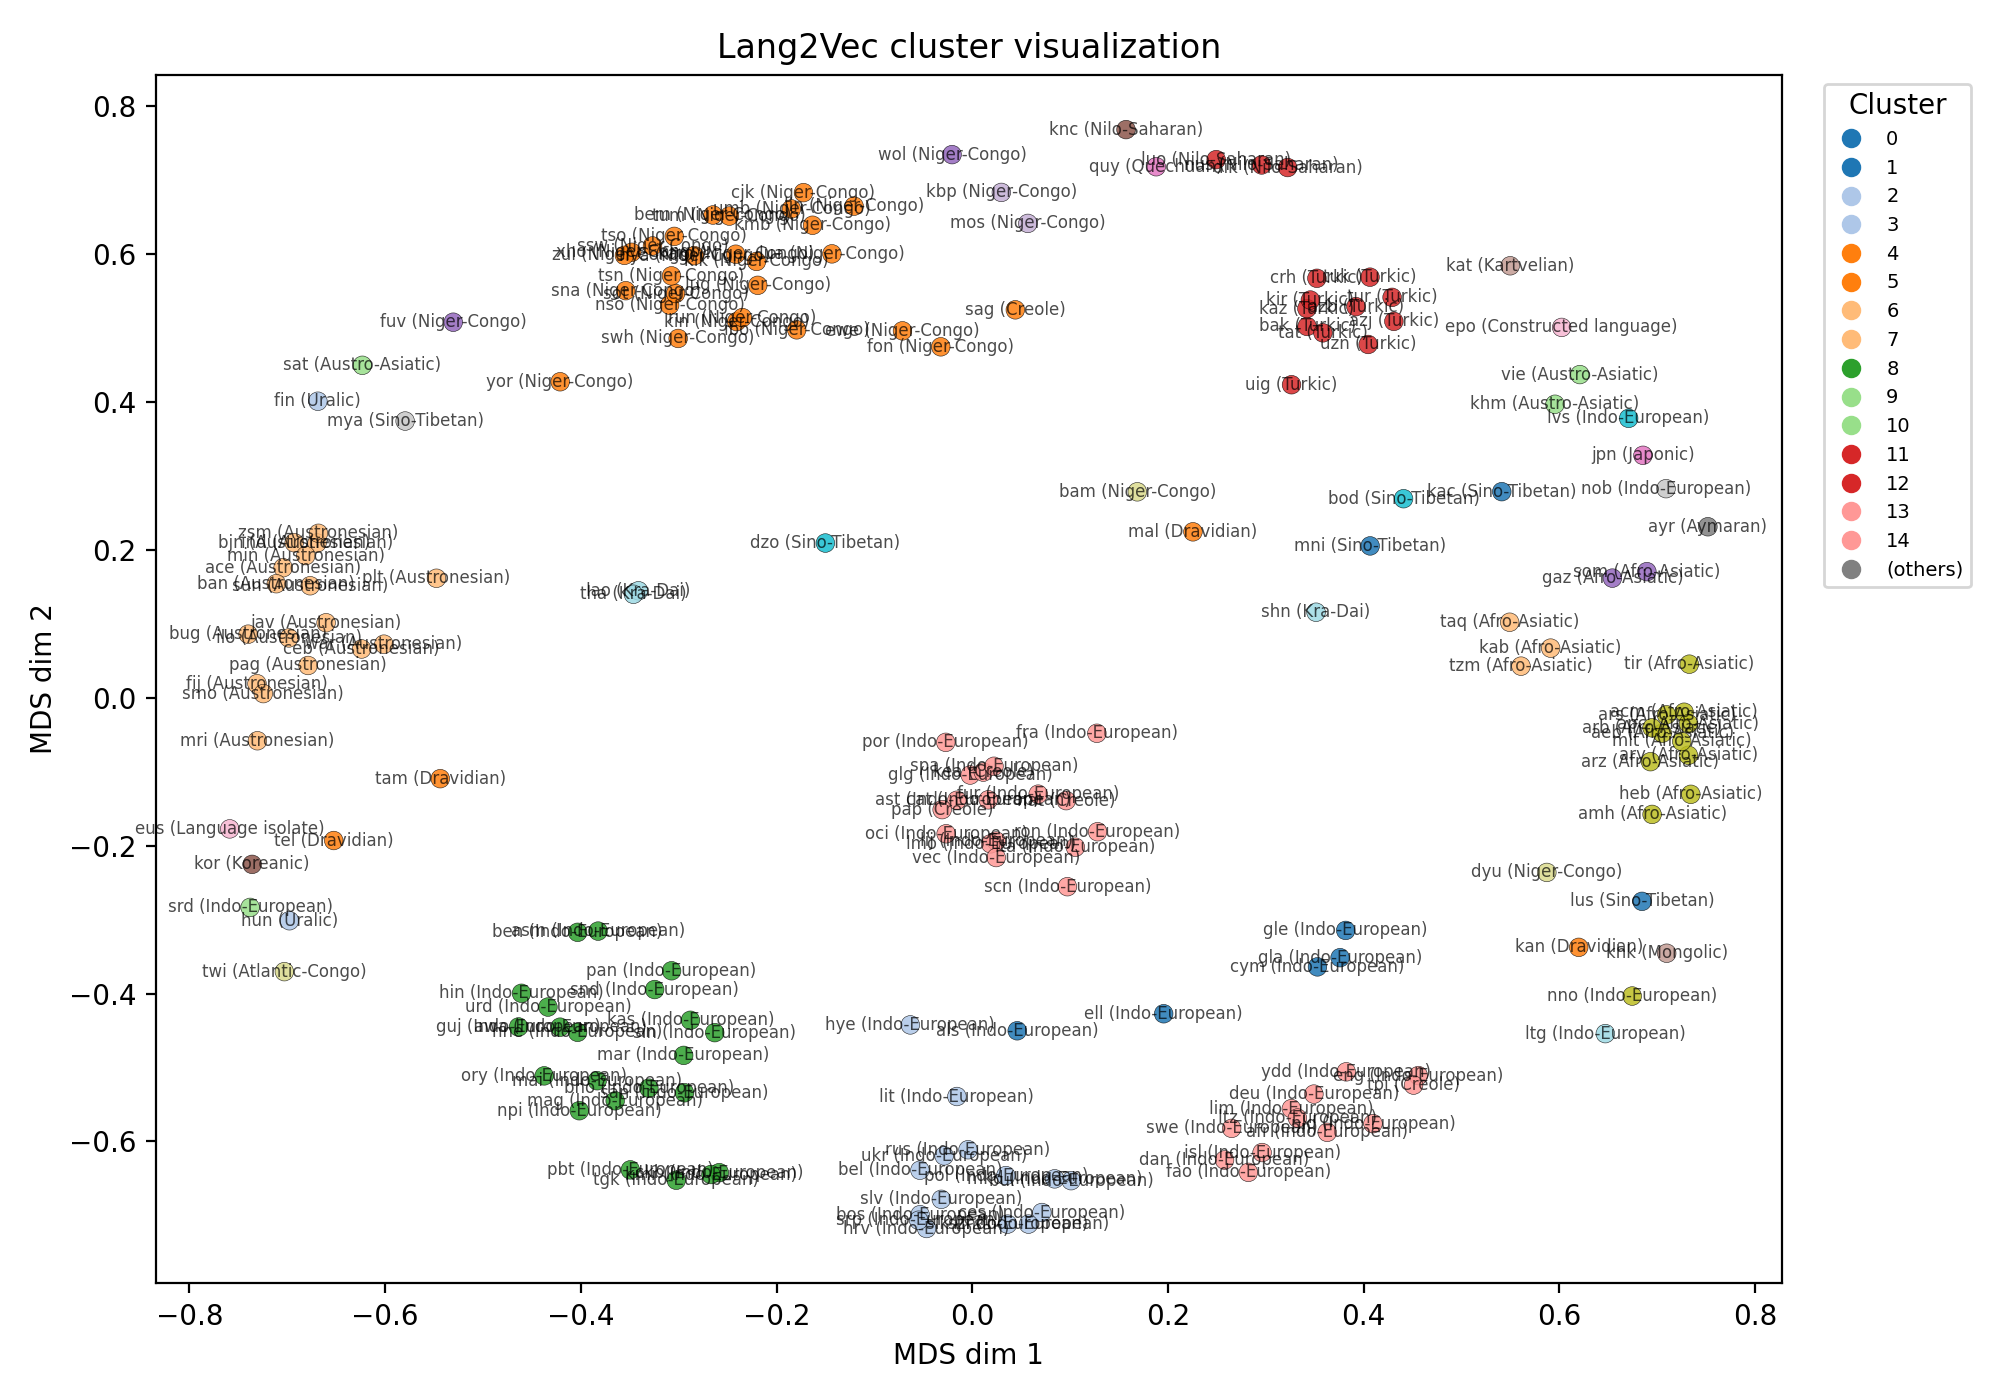

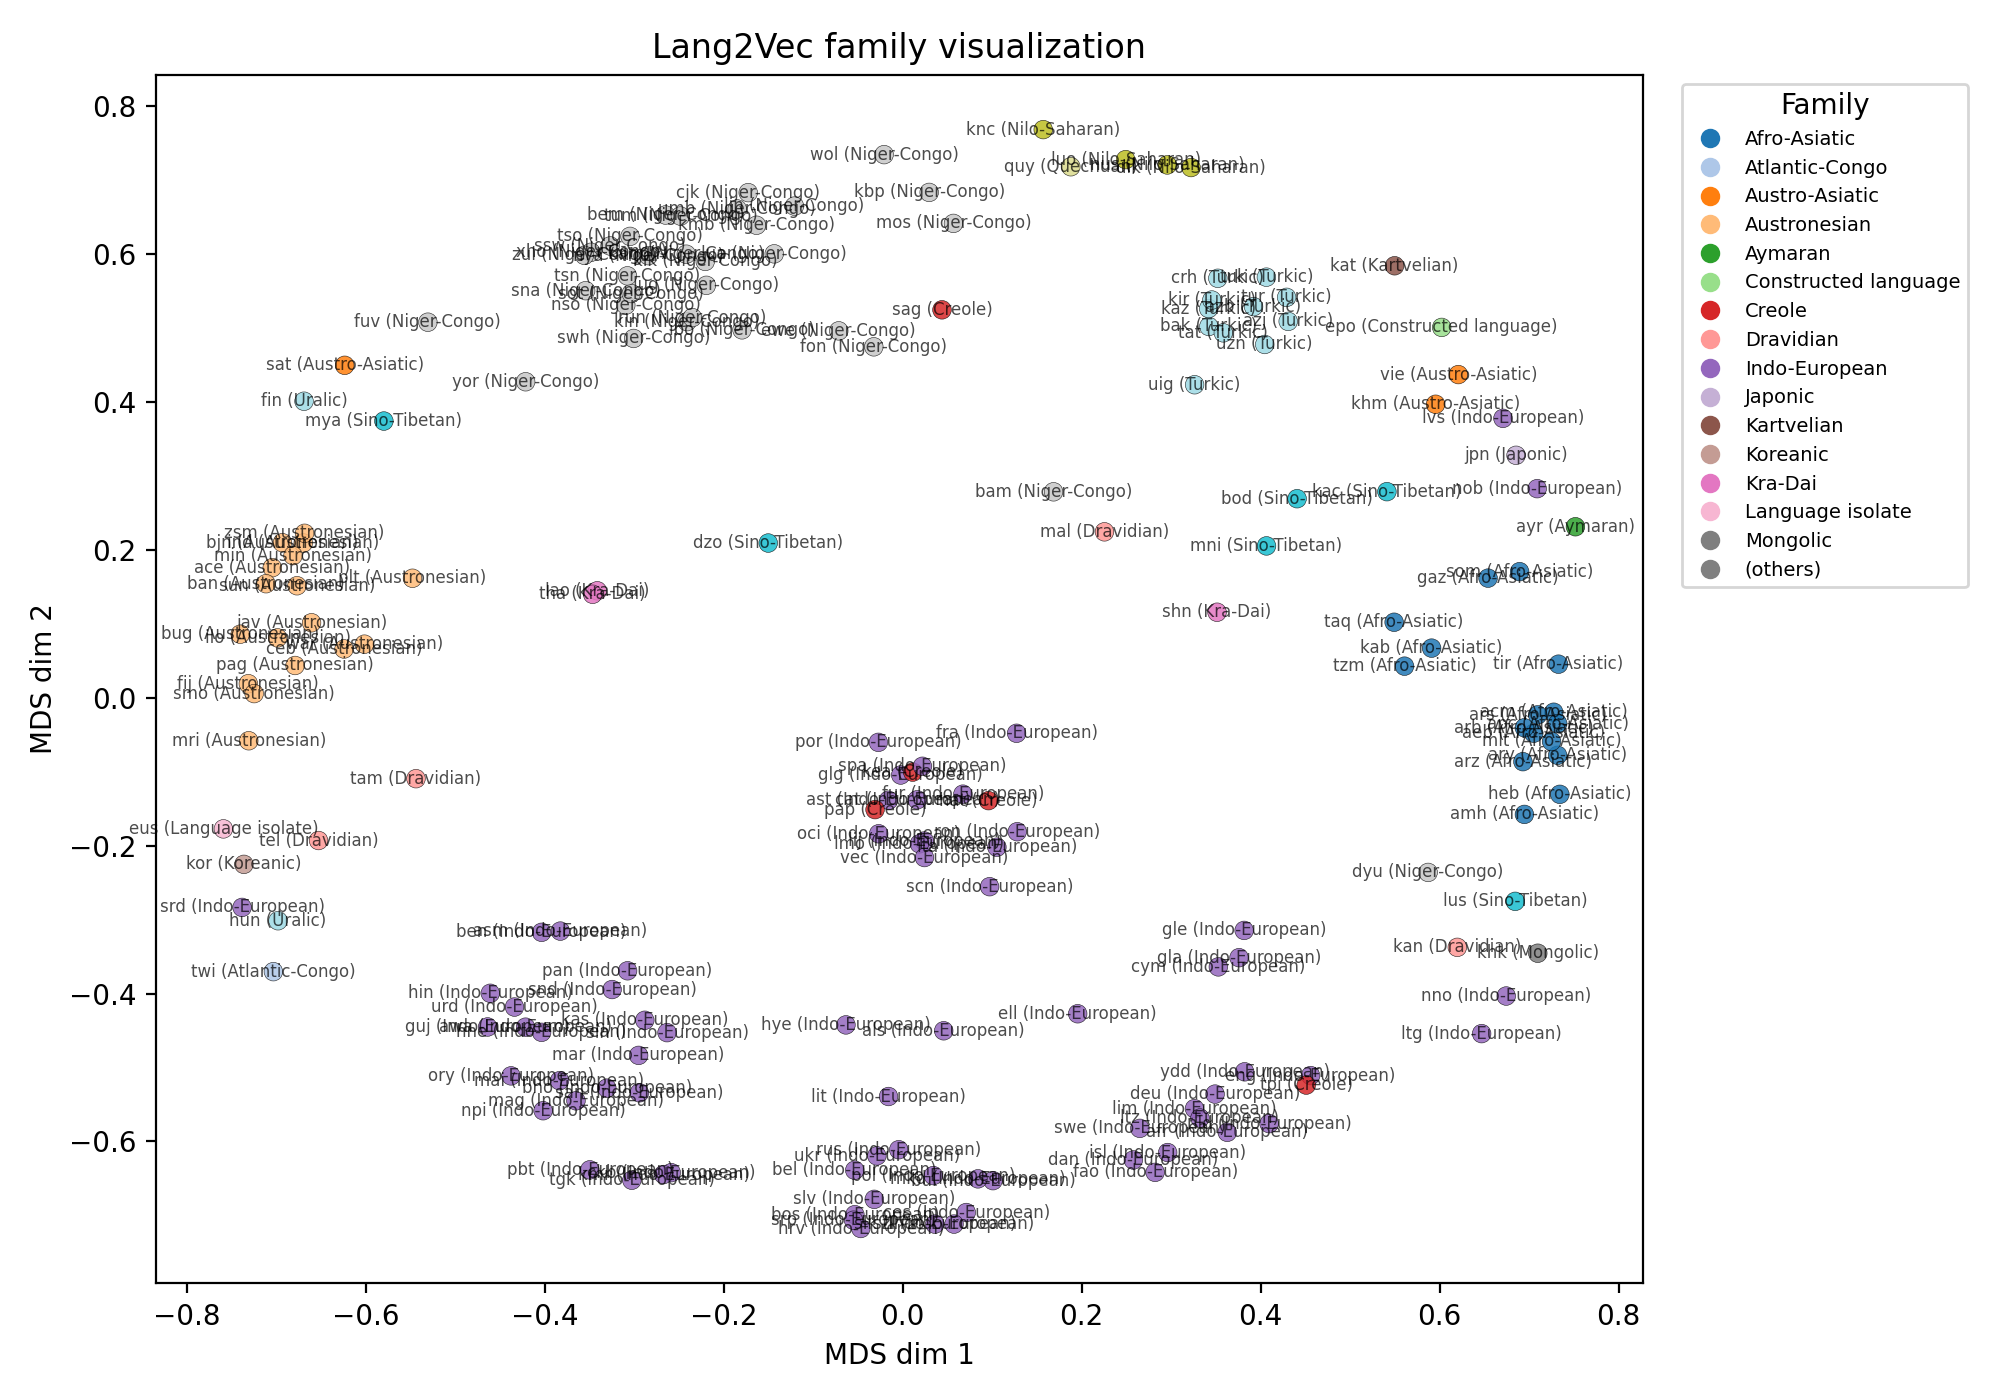

In [196]:
plots_dir = PROCESSED_DIR / 'notebook_plots'
plots_dir.mkdir(exist_ok=True, parents=True)
plot_distance_projection(matrix, langs, families, labels, plots_dir / 'mds_by_cluster.png', 'cluster')
plot_distance_projection(matrix, langs, families, labels, plots_dir / 'mds_by_family.png', 'family')
display(Image(filename=str(plots_dir / 'mds_by_cluster.png')))
display(Image(filename=str(plots_dir / 'mds_by_family.png')))

## Silhouette diagnostics

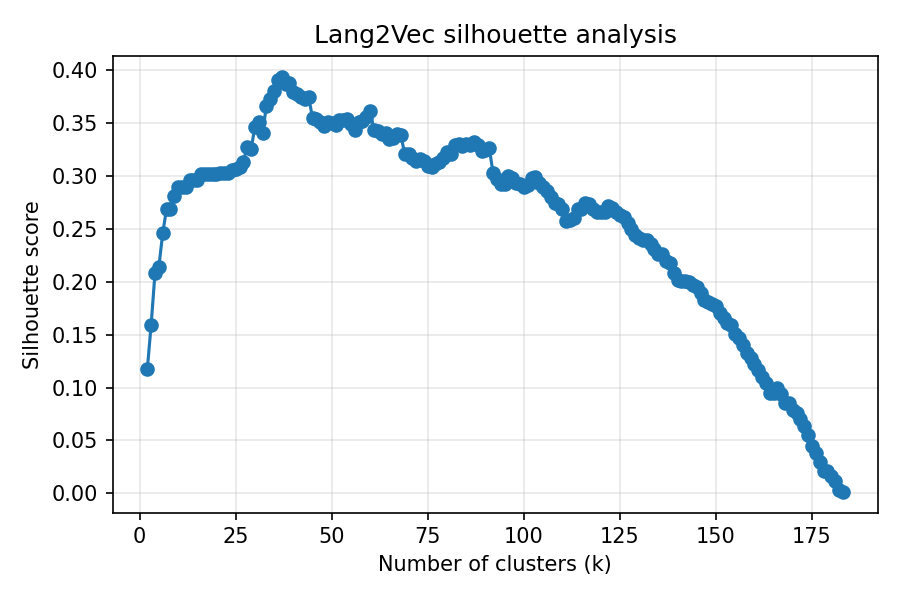

Max silhouette score at k = 37


In [197]:
plot_silhouette(silhouette_scores, plots_dir / 'silhouette_sweep.png')
display(Image(filename=str(plots_dir / 'silhouette_sweep.png')))
print("Max silhouette score at k =", k)

In [198]:
sil_vals = compute_silhouettes(matrix, labels)
if sil_vals is None:
    raise RuntimeError('Silhouette values required for tier selection')

## Build the three tiers

In [199]:
tier1_cfg = dict(best_clusters=4, seed_per_cluster=6, low_perf_per_cluster=3, low_perf_threshold=0.35)
tier2_cfg = dict(min_count=95, max_count=95, min_per_cluster=1)
accuracy_csv = PROJECT_ROOT / 'result_analysis' / 'lm_eval' / 'belebele_llama31_8b_accuracy.csv'
low_perf_csv = accuracy_csv if accuracy_csv.exists() else None

In [200]:
seed = select_top_per_cluster(
    langs,
    families,
    labels,
    sil_vals,
    tier1_cfg['seed_per_cluster'],
    PROCESSED_DIR / 'notebook_tier1_candidates.json',
    best_clusters=tier1_cfg['best_clusters'],
)
from cluster_lang2vec_distances import filter_low_performance_selection
tier1 = filter_low_performance_selection(
    seed,
    tier1_cfg['low_perf_per_cluster'],
    tier1_cfg['low_perf_threshold'],
    low_perf_csv,
    PROCESSED_DIR / 'notebook_tier1.json',
    report_path=None,
)
len(tier1)
tier1[:2]

[{'code': 'ilo',
  'family': 'Austronesian',
  'cluster': 6,
  'silhouette': 0.52638125,
  'cluster_rank': 2,
  'accuracy': 0.32,
  'subset': 'ilo_Latn'},
 {'code': 'sun',
  'family': 'Austronesian',
  'cluster': 6,
  'silhouette': 0.528775,
  'cluster_rank': 1,
  'accuracy': 0.384,
  'subset': 'sun_Latn'}]

In [201]:
stats = build_cluster_stats(labels, sil_vals)
all_clusters = sorted(set(int(x) for x in labels))
tier2_clusters, tier2_indices, partial_cluster = select_tier2_clusters(
    stats,
    sil_vals,
    tier2_cfg['min_count'],
    tier2_cfg['max_count'],
    tier2_cfg['min_per_cluster'],
    all_clusters,
)
tier2 = [
    {
        'code': langs[idx],
        'family': families[idx],
        'cluster': int(labels[idx]),
        'silhouette': float(sil_vals[idx]),
    }
    for idx in tier2_indices
]
json.dump(tier2, open(PROCESSED_DIR / 'notebook_tier2.json', 'w'), indent=2)
len(tier2)
sorted(set(entry['cluster'] for entry in tier2))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36]

## Tier selection visuals

/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Highlight plot saved to /home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/processed_artifacts/notebook_plots/tier1_selection.png


/home/ubuntu/miniconda3/envs/cola_llama_factory/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Highlight plot saved to /home/ubuntu/dice_repos/HTYLLM-PG/approaches/CoLA/data_prep/processed_artifacts/notebook_plots/tier2_selection.png


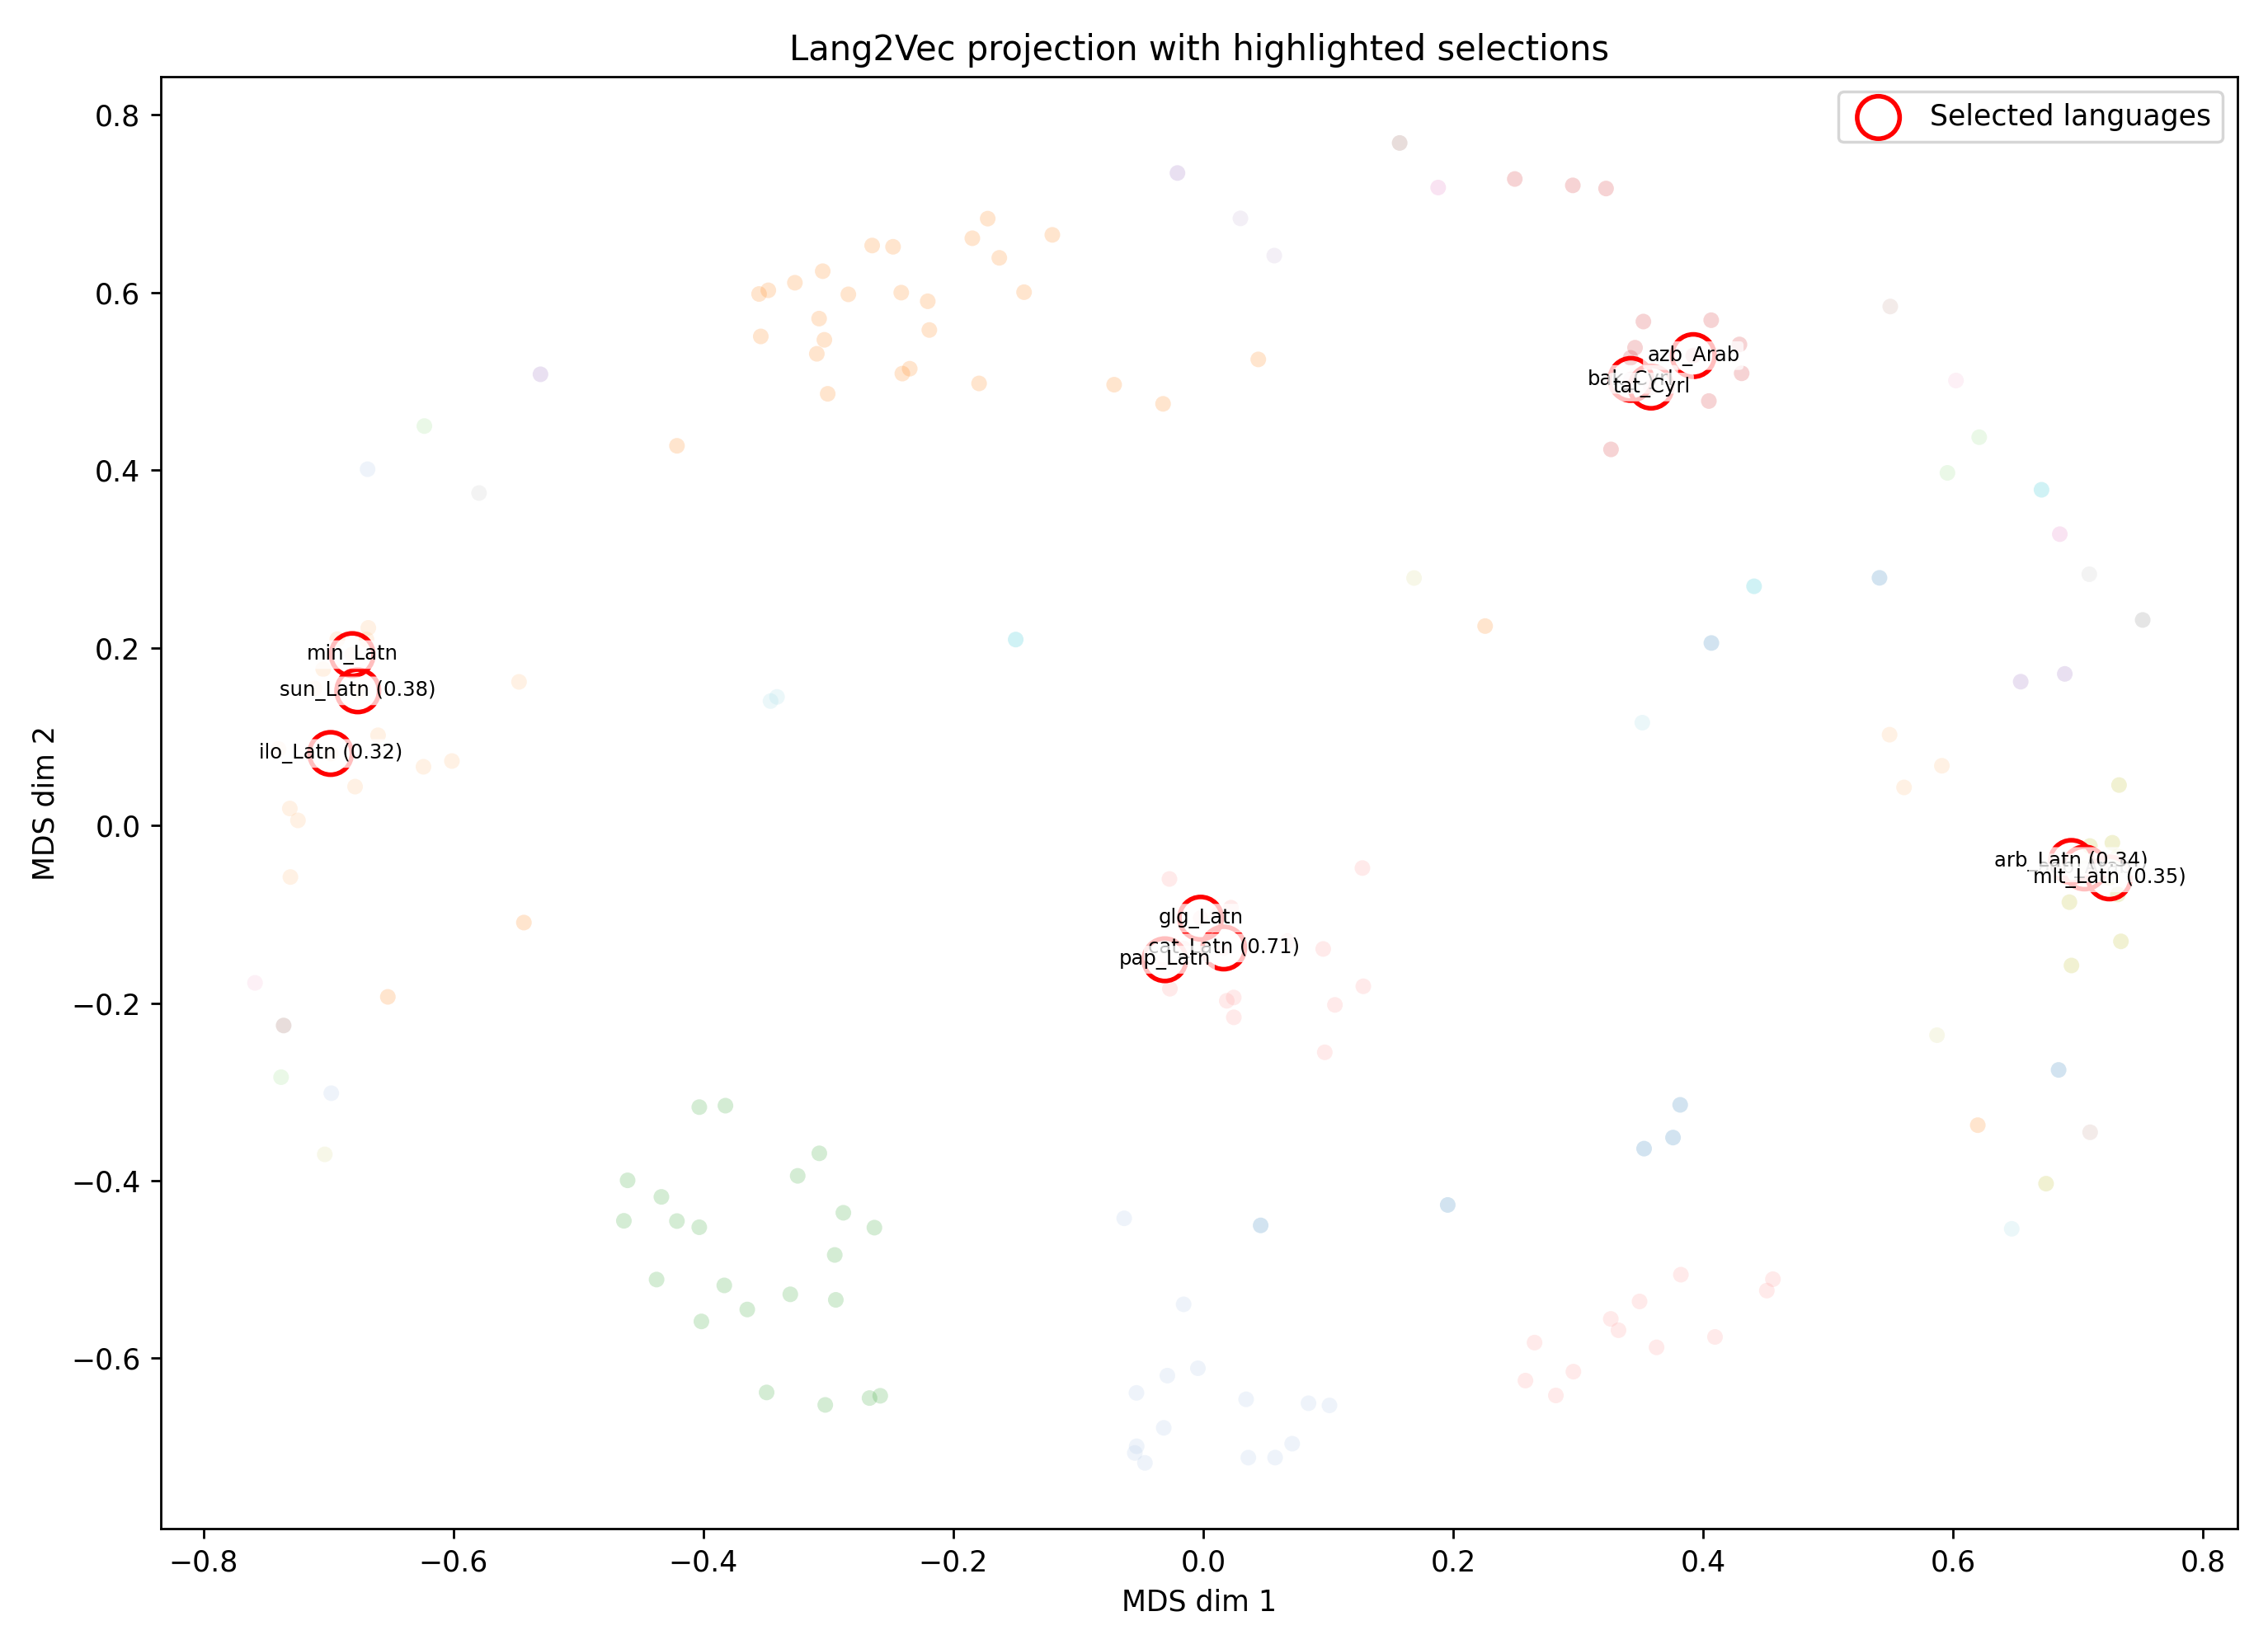

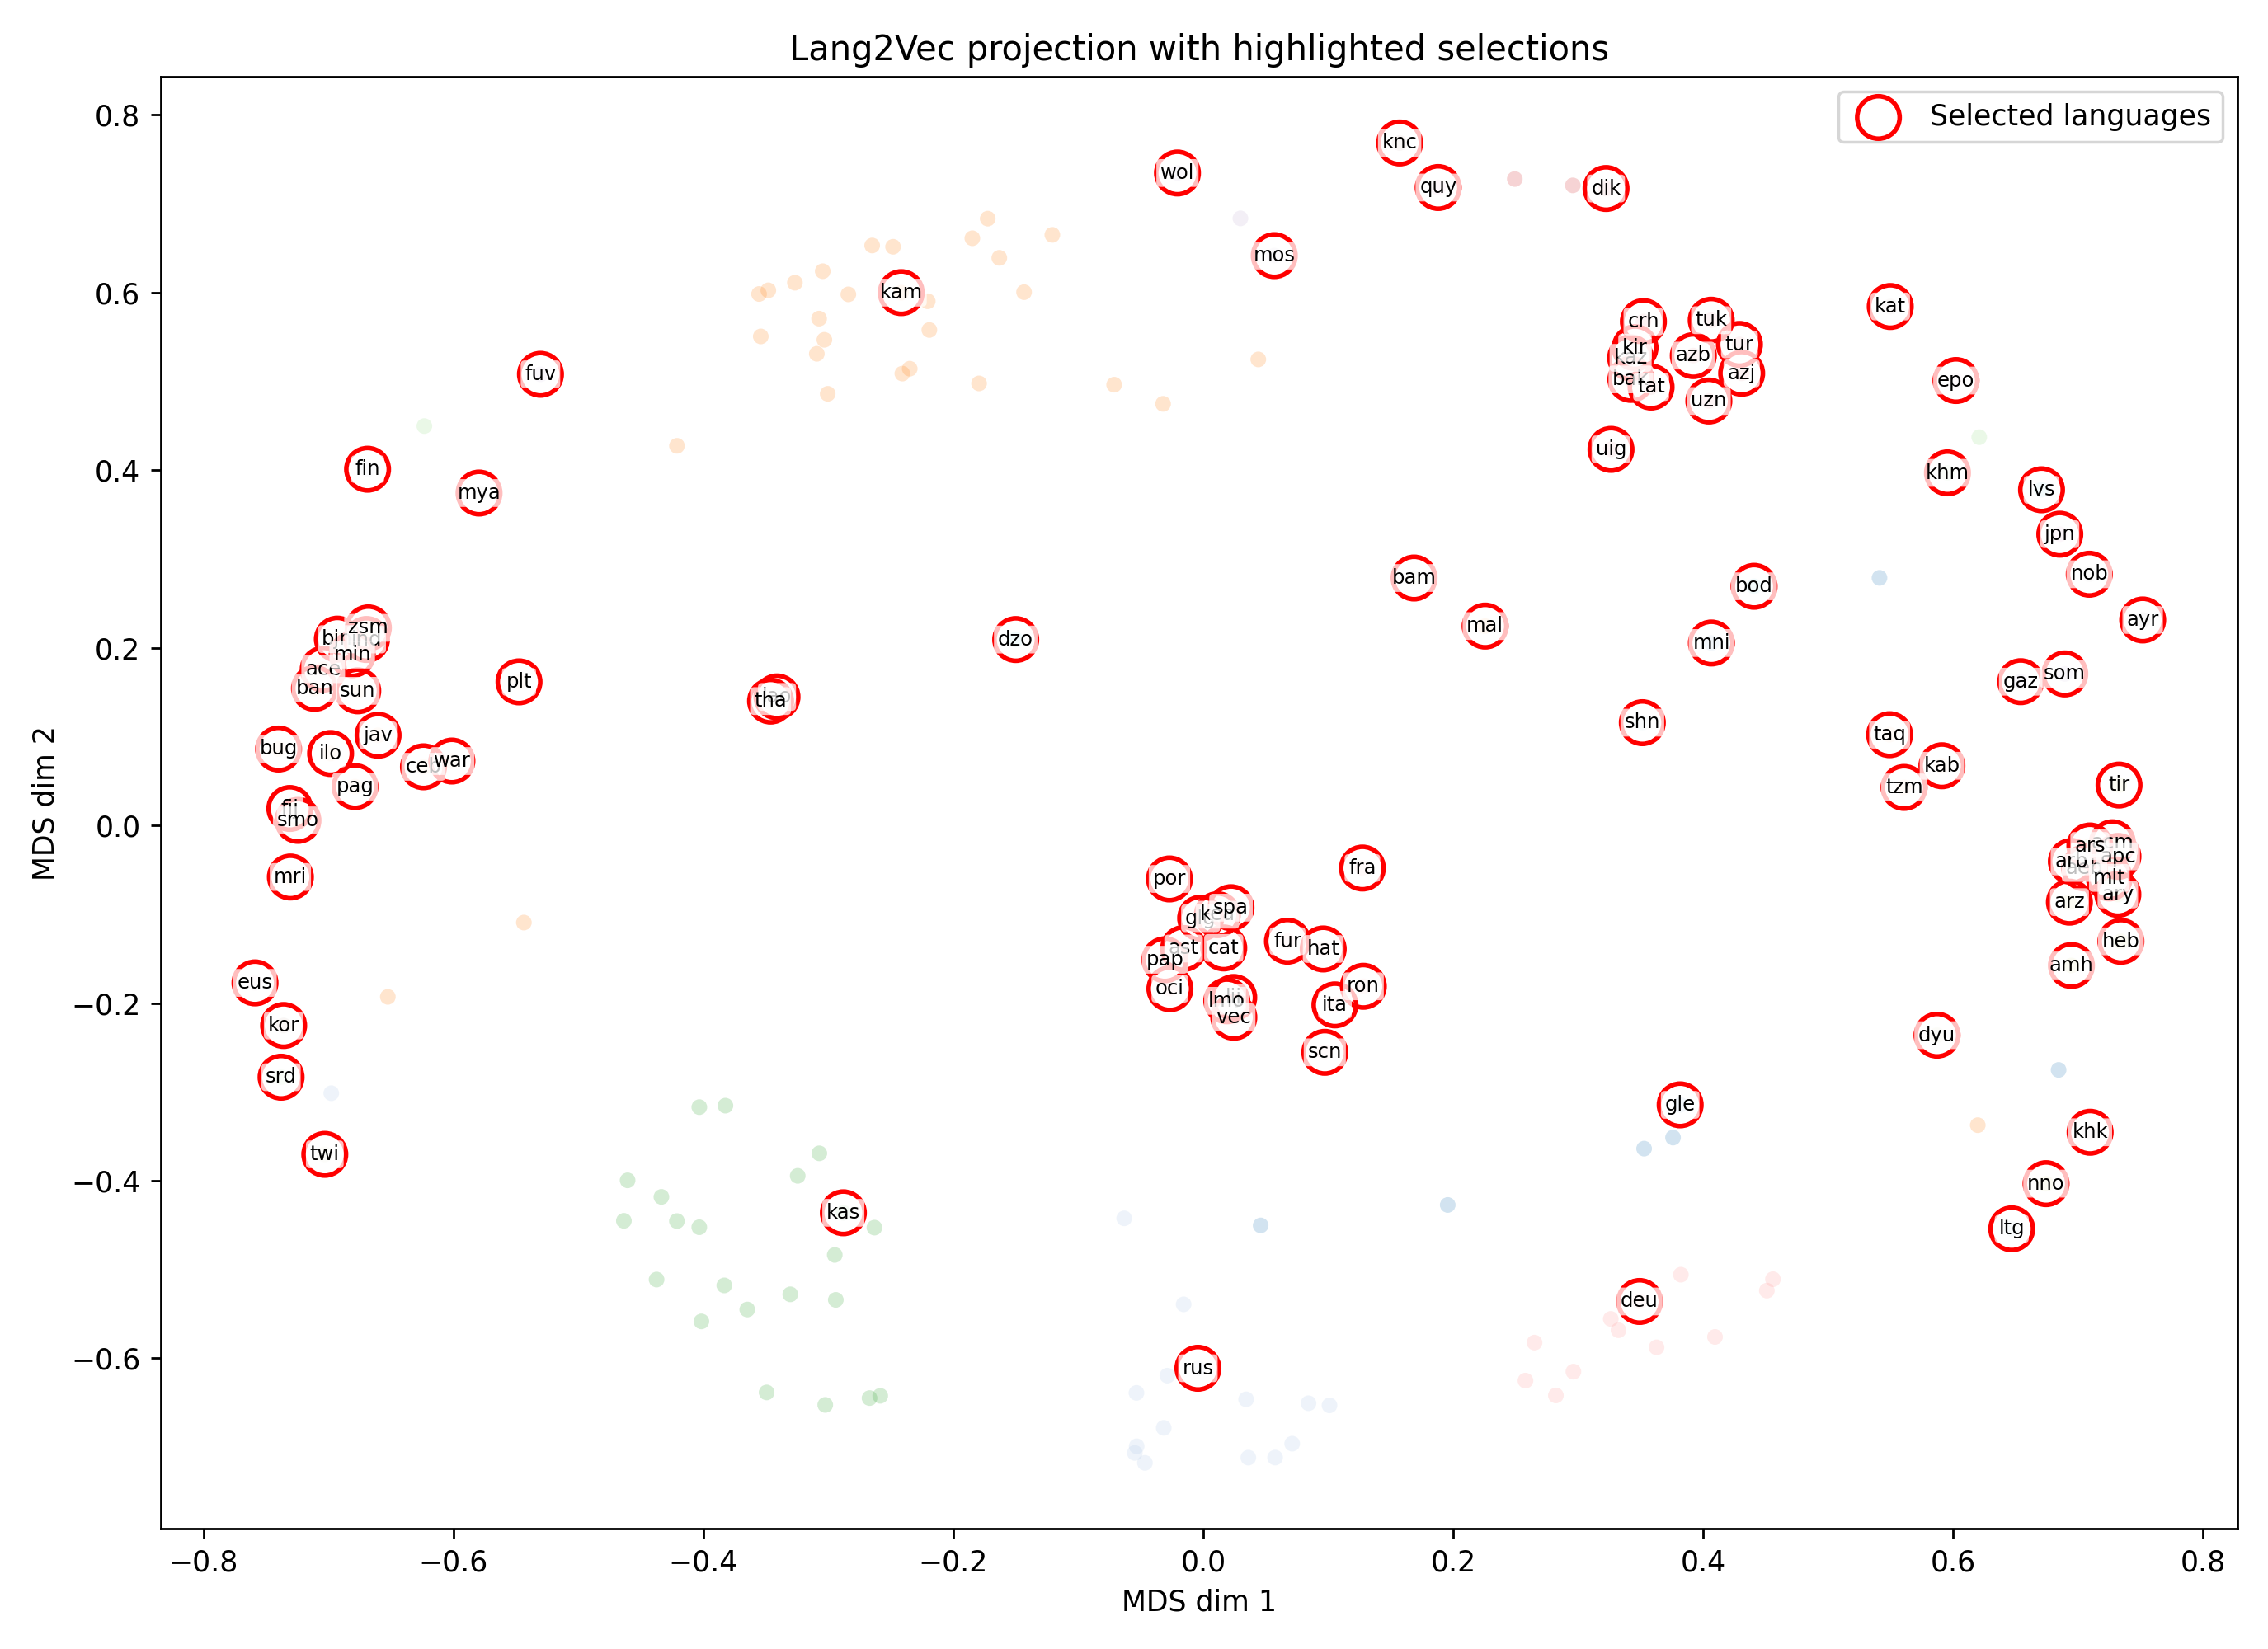

In [202]:
plot_selection_highlight(matrix, langs, labels, tier1, plots_dir / 'tier1_selection.png')
plot_selection_highlight(matrix, langs, labels, tier2, plots_dir / 'tier2_selection.png')
display(Image(filename=str(plots_dir / 'tier1_selection.png')))
display(Image(filename=str(plots_dir / 'tier2_selection.png')))

In [203]:
summary = {
    'tier1': {'languages': len(tier1)},
    'tier2': {'languages': len(tier2), 'clusters': sorted(set(entry['cluster'] for entry in tier2))},
    'tier3': {'languages': len(langs), 'clusters': sorted(set(int(x) for x in labels))},
}
summary

{'tier1': {'languages': 12},
 'tier2': {'languages': 97,
  'clusters': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36]},
 'tier3': {'languages': 184,
  'clusters': [0,
   1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36]}}